<a href="https://colab.research.google.com/github/seno20/Final_Project/blob/main/Rainfall_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Library

In [207]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('default')

### Load Dataset

In [208]:
pd.set_option('display.max_columns', None)

In [209]:
# Load data
df = pd.read_csv('rainfall.csv', sep=';')

# Ubah Tanggal
df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='%d/%m/%Y')

# Ubah semua kolom numerik
for col in df.columns.drop('Tanggal'):
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(',', '.'),
        errors='coerce'
    )

print('Shape:', df.shape)
df.head()

Shape: (1496, 24)


,Tanggal,AF01,AF02,AF03,AF04,AF05,AF06,AF07,AF08,AF09,AF10,AF11,AF12,AF13,AF14,AF15,AF16,AF17,AF18,AF19,AF20,RY01,RY02,RY03
0,2021-01-01,10.0,0.0,0.0,10.0,0.0,0.0,11.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2021-01-02,5.0,11.0,2.5,5.0,2.5,11.0,5.0,5.0,7.8,16.0,16.0,16.0,18.2,18.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2021-01-03,23.0,10.6,23.5,23.0,23.5,10.6,12.8,12.8,10.2,19.0,19.0,19.0,12.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2021-01-04,7.0,5.0,1.5,7.0,1.5,5.0,4.0,4.0,2.8,2.0,2.0,2.0,7.2,7.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2021-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.6,4.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [210]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1496 entries, 0 to 1495
Data columns (total 24 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Tanggal  1496 non-null   datetime64[ns]
 1   AF01     1458 non-null   float64       
 2   AF02     1454 non-null   float64       
 3   AF03     1454 non-null   float64       
 4   AF04     1455 non-null   float64       
 5   AF05     1461 non-null   float64       
 6   AF06     1452 non-null   float64       
 7   AF07     1457 non-null   float64       
 8   AF08     1455 non-null   float64       
 9   AF09     1463 non-null   float64       
 10  AF10     1454 non-null   float64       
 11  AF11     1453 non-null   float64       
 12  AF12     1451 non-null   float64       
 13  AF13     1453 non-null   float64       
 14  AF14     1456 non-null   float64       
 15  AF15     1458 non-null   float64       
 16  AF16     1445 non-null   float64       
 17  AF17     1438 non-null   float64 

## Exploratory Data Analysis

In [211]:
# Drop Table yg tidak dibutuhkan
columns_to_drop = [
    'AF18',
    'AF19',
    'AF20',
    'RY01',
    'RY02',
    'RY03'
]

# Filter kolom yang tidak ada dalam DataFrame untuk mencegah KeyError
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]

if existing_columns_to_drop:
    df = df.drop(columns=existing_columns_to_drop)
    print(f"Kolom yang berhasil dihapus: {existing_columns_to_drop}")
else:
    print("Semua kolom yang ingin dihapus sudah tidak ada di DataFrame.")

df.head()

Kolom yang berhasil dihapus: ['AF18', 'AF19', 'AF20', 'RY01', 'RY02', 'RY03']


,Tanggal,AF01,AF02,AF03,AF04,AF05,AF06,AF07,AF08,AF09,AF10,AF11,AF12,AF13,AF14,AF15,AF16,AF17
0,2021-01-01,10.0,0.0,0.0,10.0,0.0,0.0,11.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2021-01-02,5.0,11.0,2.5,5.0,2.5,11.0,5.0,5.0,7.8,16.0,16.0,16.0,18.2,18.2,0.0,0.0,0.0
2,2021-01-03,23.0,10.6,23.5,23.0,23.5,10.6,12.8,12.8,10.2,19.0,19.0,19.0,12.0,12.0,0.0,0.0,0.0
3,2021-01-04,7.0,5.0,1.5,7.0,1.5,5.0,4.0,4.0,2.8,2.0,2.0,2.0,7.2,7.2,0.0,0.0,0.0
4,2021-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.6,4.6,0.0,0.0,0.0


###Cek Missing Value

In [212]:
df.isnull().sum()

,0
Tanggal,0
AF01,38
AF02,42
AF03,42
AF04,41
AF05,35
AF06,44
AF07,39
AF08,41
AF09,33


In [213]:
# Fill missing values with the mean of each column
for col in df.columns:
    if df[col].isnull().any(): # Check if the column has any missing values
        if df[col].dtype == 'float64': # Ensure it's a numeric column suitable for mean imputation
            mean_value = df[col].mean()
            df[col] = df[col].fillna(mean_value)
            print(f"Missing values in column '{col}' filled with mean: {mean_value:.2f}")

# Verify that there are no more missing values
print("\nMissing values after imputation:")
df.isnull().sum()

Missing values in column 'AF01' filled with mean: 11.84
Missing values in column 'AF02' filled with mean: 11.04
Missing values in column 'AF03' filled with mean: 10.80
Missing values in column 'AF04' filled with mean: 10.74
Missing values in column 'AF05' filled with mean: 9.89
Missing values in column 'AF06' filled with mean: 11.42
Missing values in column 'AF07' filled with mean: 9.81
Missing values in column 'AF08' filled with mean: 8.40
Missing values in column 'AF09' filled with mean: 9.99
Missing values in column 'AF10' filled with mean: 9.92
Missing values in column 'AF11' filled with mean: 10.48
Missing values in column 'AF12' filled with mean: 10.55
Missing values in column 'AF13' filled with mean: 10.35
Missing values in column 'AF14' filled with mean: 10.34
Missing values in column 'AF15' filled with mean: 9.43
Missing values in column 'AF16' filled with mean: 5.20
Missing values in column 'AF17' filled with mean: 5.57

Missing values after imputation:


,0
Tanggal,0
AF01,0
AF02,0
AF03,0
AF04,0
AF05,0
AF06,0
AF07,0
AF08,0
AF09,0


### Visualisasi Tren Curah Hujan Harian

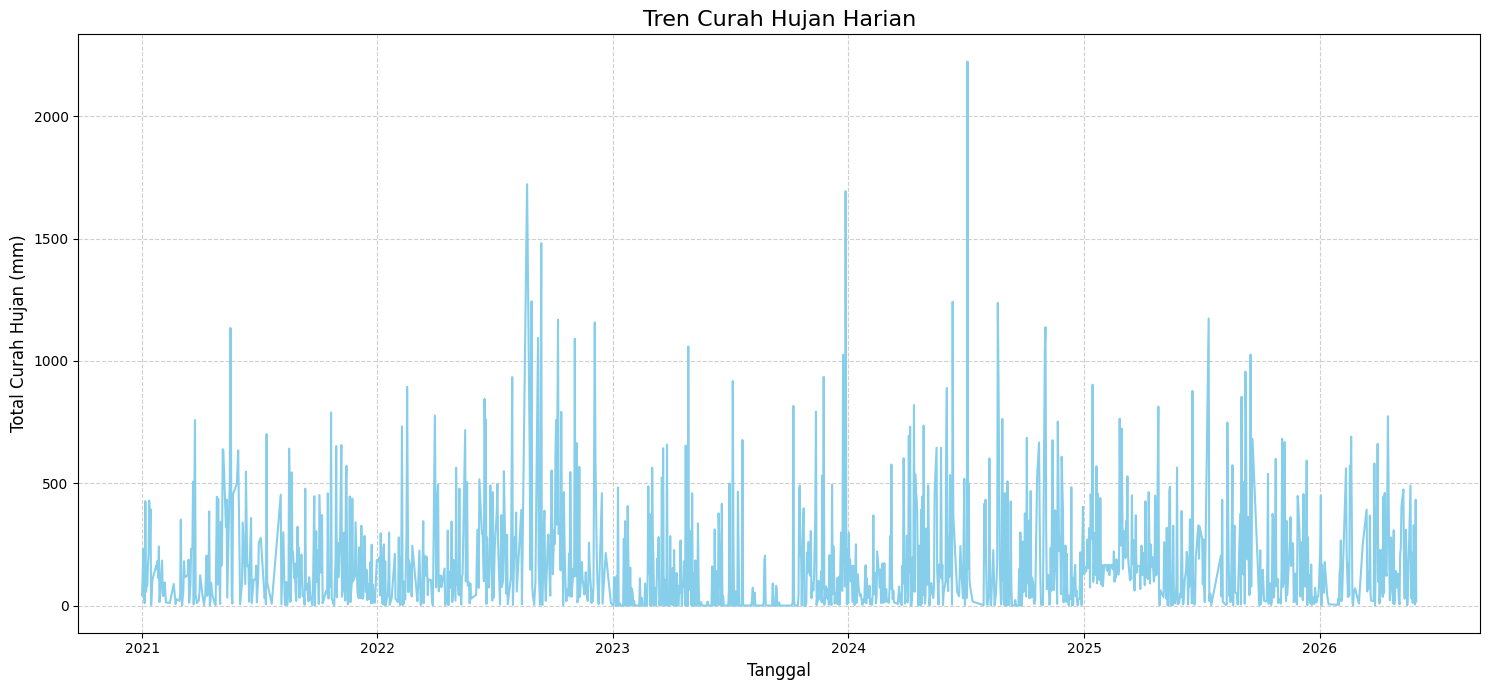

In [214]:
# Calculate total daily rainfall by summing across all 'AF' columns
rainfall_cols = [col for col in df.columns if col.startswith('AF')]
df['Total_Curah_Hujan'] = df[rainfall_cols].sum(axis=1)

# Set 'Tanggal' as the index for time series plotting
df_plot = df[['Tanggal', 'Total_Curah_Hujan']].set_index('Tanggal')

plt.figure(figsize=(15, 7))
sns.lineplot(data=df_plot, x=df_plot.index, y='Total_Curah_Hujan', color='skyblue')
plt.title('Tren Curah Hujan Harian', fontsize=16)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Total Curah Hujan (mm)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

  ### Dry Spell (Musim Kering)

In [215]:
### Identifikasi Musim Kering

# Define a dry day (e.g., Total_Curah_Hujan == 0)
df['is_dry_day'] = df['Total_Curah_Hujan'] == 0

# Calculate consecutive dry days
df['consecutive_dry_days'] = df['is_dry_day'].groupby((df['is_dry_day'] != df['is_dry_day'].shift()).cumsum()).transform('sum')

# Filter for actual dry spells (where is_dry_day is True)
dry_spells = df[df['is_dry_day'] == True]

# Define a threshold for a 'dry season' (e.g., 7 consecutive dry days)
dry_season_threshold = 7

# Find dry season periods
dry_season_periods = dry_spells[dry_spells['consecutive_dry_days'] >= dry_season_threshold]

if not dry_season_periods.empty:
    print(f"Musim kering (periode dengan setidaknya {dry_season_threshold} hari tanpa hujan):")
    # Group by the start of each dry spell
    dry_season_groups = dry_season_periods.groupby((dry_season_periods['Tanggal'].diff() != pd.Timedelta(days=1)).cumsum())

    for name, group in dry_season_groups:
        start_date = group['Tanggal'].min().strftime('%Y-%m-%d')
        end_date = group['Tanggal'].max().strftime('%Y-%m-%d')
        duration = group['consecutive_dry_days'].max()
        if duration >= dry_season_threshold:
            print(f"  Periode: {start_date} sampai {end_date} (Durasi: {duration} hari tanpa hujan)")
else:
    print(f"Tidak ada musim kering yang teridentifikasi (periode tanpa hujan setidaknya {dry_season_threshold} hari).")

Musim kering (periode dengan setidaknya 7 hari tanpa hujan):
  Periode: 2023-02-05 sampai 2023-02-11 (Durasi: 7 hari tanpa hujan)
  Periode: 2023-05-20 sampai 2023-05-27 (Durasi: 8 hari tanpa hujan)
  Periode: 2023-06-22 sampai 2023-06-29 (Durasi: 8 hari tanpa hujan)
  Periode: 2023-07-22 sampai 2023-08-01 (Durasi: 11 hari tanpa hujan)
  Periode: 2023-08-10 sampai 2023-08-22 (Durasi: 13 hari tanpa hujan)
  Periode: 2023-08-26 sampai 2023-09-05 (Durasi: 11 hari tanpa hujan)
  Periode: 2023-09-17 sampai 2023-10-05 (Durasi: 19 hari tanpa hujan)


###Agregasi CH Bulanan

In [216]:
df_monthly_sum = df.set_index('Tanggal')['Total_Curah_Hujan'].resample('ME').sum()

print("Agregasi Curah Hujan Bulanan:")
print(df_monthly_sum.head())

Agregasi Curah Hujan Bulanan:
Tanggal
2021-01-31    3578.90
2021-02-28     570.32
2021-03-31    3703.30
2021-04-30    2351.80
2021-05-31    6113.40
Freq: ME, Name: Total_Curah_Hujan, dtype: float64


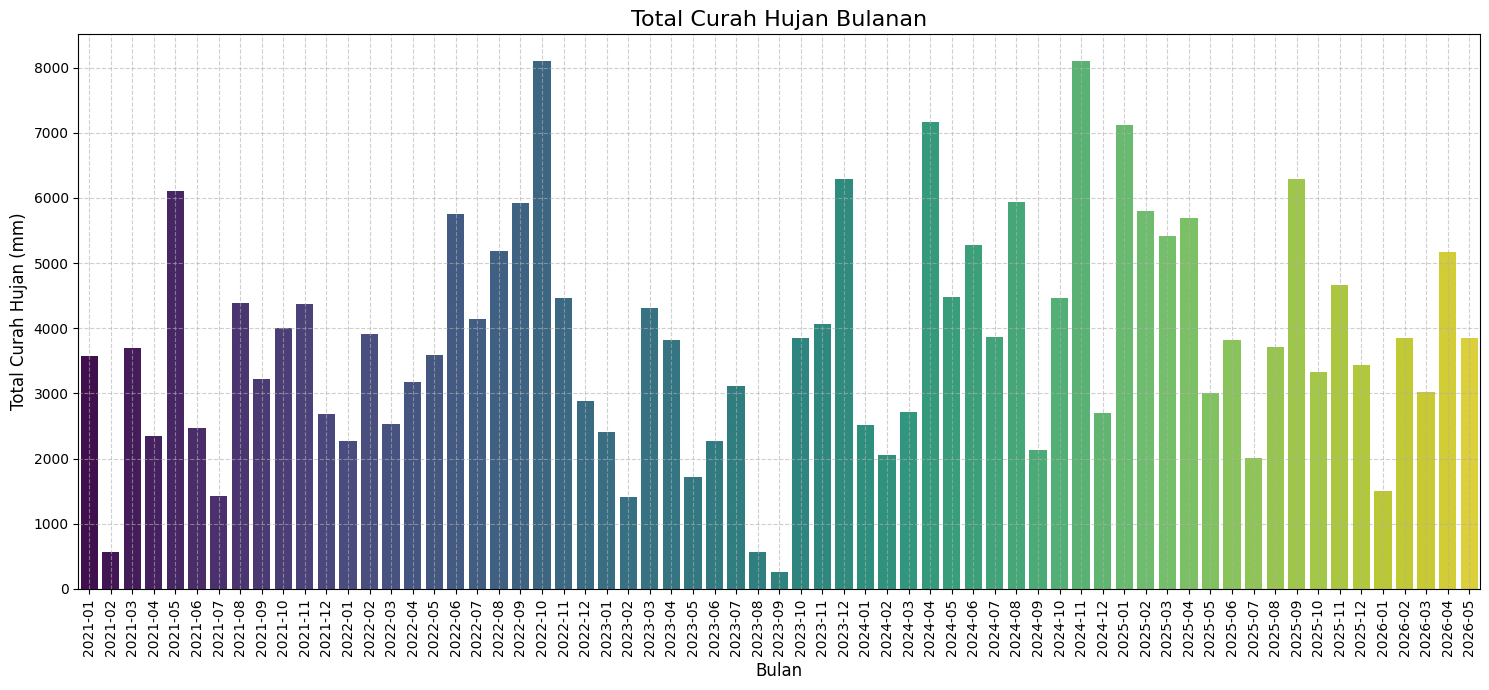

In [217]:
#Visualisasi Agregasi CH Bulanan
plt.figure(figsize=(15, 7))
sns.barplot(x=df_monthly_sum.index.strftime('%Y-%m'), y=df_monthly_sum.values, hue=df_monthly_sum.index.strftime('%Y-%m'), palette='viridis', legend=False)
plt.title('Total Curah Hujan Bulanan', fontsize=16)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Total Curah Hujan (mm)', fontsize=12)
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Rata-rata Curah Hujan Bulanan

In [218]:
df_monthly_avg = df.set_index('Tanggal')['Total_Curah_Hujan'].resample('ME').mean()

print("Rata-rata Curah Hujan Bulanan:")
print(df_monthly_avg.head())

Rata-rata Curah Hujan Bulanan:
Tanggal
2021-01-31    155.604348
2021-02-28     51.847273
2021-03-31    161.013043
2021-04-30    117.590000
2021-05-31    382.087500
Freq: ME, Name: Total_Curah_Hujan, dtype: float64


### Hitung SWR dan WD Actual
SWR (Soil Water Reserve)
WD (Water Deficit)

In [219]:
# Definisikan SWR dan WD
ETP_MONTHLY = 120  # Monthly Evapotranspiration in mm
SWR_MAX_CAPACITY = 200 # Maximum Soil Water Retention capacity in mm

# Get 'AF' columns for rainfall calculation
af_cols = [c for c in df.columns if c.startswith('AF')]

# Calculate average daily rainfall (CH) across all 'AF' columns
df['CH'] = df[af_cols].mean(axis=1)

# IMPORTANT: Explicitly convert 'CH' to numeric type, coercing any non-numeric (like NaT) to NaN
df['CH'] = pd.to_numeric(df['CH'], errors='coerce')

# Initialize lists to store daily SWR and WD values
daily_swr = []
daily_wd = []

# Initialize current Soil Water Retention to its maximum capacity for the start of the simulation
current_swr = SWR_MAX_CAPACITY

# Iterate through each day to calculate SWR and WD
for index, row in df.iterrows():
    # Get daily rainfall
    ch_today = row['CH']

    # Skip calculation if ch_today is NaN (missing rainfall data for the day)
    if pd.isna(ch_today):
        daily_swr.append(np.nan)
        daily_wd.append(np.nan)
        continue

    # Calculate daily ETP by distributing monthly ETP over days in current month
    # (assuming ETP_MONTHLY is indeed a monthly rate)
    days_in_month = row['Tanggal'].days_in_month
    etp_daily = ETP_MONTHLY / days_in_month

    # 1. Calculate SWR (Soil Water Retention) for today based on user's rules
    # SWR_potential = SWR_previous + CH - ETP
    potential_swr = current_swr + ch_today - etp_daily

    # Apply SWR limits: SWR cannot be less than 0 or greater than SWR_MAX_CAPACITY
    # If (SWR hari sblm + CH - ETP) < 0 hasilnya 0
    # If (SWR hari sblm + CH - ETP) > 200 hasilnya 200
    # Jika tidak (SWR hari sblm + CH - ETP)
    current_swr = max(0, min(SWR_MAX_CAPACITY, potential_swr))
    daily_swr.append(current_swr)

    # 2. Calculate Water Deficit (WD) for today based on user's rules
    # WD = ETP - (CH + SWR) < 0, 0
    # Jika Tidak WD = ETP - (CH + SWR)
    # This implies WD is 0 if the raw deficit is negative (meaning surplus), else it's the raw deficit.
    wd_today = max(0, etp_daily - (ch_today + current_swr))
    daily_wd.append(wd_today)

# Add the calculated daily SWR and WD to the DataFrame
df['Daily_SWR'] = daily_swr
df['Daily_Water_Deficit'] = daily_wd

print("First 5 entries of DataFrame with Daily CH, SWR, and Water Deficit:")
display(df[['Tanggal', 'CH', 'Daily_SWR', 'Daily_Water_Deficit']].head())

First 5 entries of DataFrame with Daily CH, SWR, and Water Deficit:


,Tanggal,CH,Daily_SWR,Daily_Water_Deficit
0,2021-01-01,2.470588,198.599620,0.0
1,2021-01-02,8.188235,200.000000,0.0
2,2021-01-03,13.588235,200.000000,0.0
3,2021-01-04,3.423529,199.552562,0.0
4,2021-01-05,0.541176,196.222770,0.0


In [220]:
# Determine the water status (Deficit or Surplus) based on 'Daily_Water_Deficit'
# Positive values = Water Deficit
# Negative values = Water Surplus
df['Daily_Water_Status'] = np.where(
    df['Daily_Water_Deficit'] > 0,
    'Deficit',
    'Surplus'
)

print("First 5 entries of DataFrame with Daily Water Status:")
display(df[['Tanggal', 'Daily_Water_Deficit', 'Daily_Water_Status']].head())

First 5 entries of DataFrame with Daily Water Status:


,Tanggal,Daily_Water_Deficit,Daily_Water_Status
0,2021-01-01,0.0,Surplus
1,2021-01-02,0.0,Surplus
2,2021-01-03,0.0,Surplus
3,2021-01-04,0.0,Surplus
4,2021-01-05,0.0,Surplus


In [221]:
ETP_MONTHLY = 120 # Monthly Evapotranspiration in mm
SWR_MAX_CAPACITY = 200 # Maximum Soil Water Retention capacity in mm
initial_swr_value = 200 # Initial SWR value

# Create a DataFrame for monthly calculations
df_monthly_calc = pd.DataFrame({
    'Monthly_Rainfall': df_monthly_sum.values
}, index=df_monthly_sum.index)

# Initialize lists to store monthly SWR and WD values
monthly_swr = []
monthly_wd = []

current_swr = initial_swr_value

# Iterate through each month to calculate SWR and WD
for month_date, monthly_rainfall in df_monthly_calc['Monthly_Rainfall'].items():
    # Calculate potential SWR for the month
    potential_swr = current_swr + monthly_rainfall - ETP_MONTHLY

    # Apply SWR limits: SWR cannot be less than 0 or greater than SWR_MAX_CAPACITY
    # Jika (SWR hari sblm + CH - ETP) < 0 hasilnya 0
    # Jika (SWR hari sblm + CH - ETP) > 200 hasilnya 200
    # Jika tidak (SWR hari sblm + CH - ETP)
    current_swr = max(0, min(SWR_MAX_CAPACITY, potential_swr))
    monthly_swr.append(current_swr)

    # Calculate Water Deficit (WD) for the month
    # WD = ETP - (CH + SWR) < 0, 0
    # Jika Tidak WD = ETP - (CH + SWR)
    # Note: CH here refers to monthly_rainfall
    wd_this_month = max(0, ETP_MONTHLY - (monthly_rainfall + current_swr))
    monthly_wd.append(wd_this_month)

# Add the calculated monthly SWR and WD to the new DataFrame
df_monthly_calc['Monthly_SWR'] = monthly_swr
df_monthly_calc['Monthly_Water_Deficit'] = monthly_wd

print("First 5 entries of Monthly Calculations with SWR and Water Deficit:")
display(df_monthly_calc.head())

# Visualizing Monthly SWR and WD
# plt.figure(figsize=(18, 8))
# plt.plot(df_monthly_calc.index.strftime('%Y-%m'), df_monthly_calc['Monthly_SWR'], label='Monthly SWR (mm)', color='green', marker='o', linewidth=2)
# plt.bar(df_monthly_calc.index.strftime('%Y-%m'), df_monthly_calc['Monthly_Rainfall'], label='Monthly Rainfall (mm)', color='blue', alpha=0.6)
# plt.plot(df_monthly_calc.index.strftime('%Y-%m'), [ETP_MONTHLY]*len(df_monthly_calc), label='Constant Monthly ETP (120mm)', color='red', linestyle='--', marker='x')
# plt.plot(df_monthly_calc.index.strftime('%Y-%m'), df_monthly_calc['Monthly_Water_Deficit'], label='Monthly Water Deficit (mm)', color='purple', linestyle='-', marker='s')

# plt.title('Monthly SWR, Rainfall, ETP, and Water Deficit', fontsize=18)
# plt.xlabel('Month', fontsize=14)
# plt.ylabel('Value (mm)', fontsize=14)
# plt.xticks(rotation=90, fontsize=10)
# plt.yticks(fontsize=10)
# plt.grid(True, linestyle='--', alpha=0.7)
# plt.legend(fontsize=12)
# plt.tight_layout()
# plt.show()

First 5 entries of Monthly Calculations with SWR and Water Deficit:


,Monthly_Rainfall,Monthly_SWR,Monthly_Water_Deficit
Tanggal,,,
2021-01-31,3578.90,200,0
2021-02-28,570.32,200,0
2021-03-31,3703.30,200,0
2021-04-30,2351.80,200,0
2021-05-31,6113.40,200,0


## Train Test Split

In [222]:
# Ensure the DataFrame is sorted by time (index is already datetime, so it should be)
df_monthly_calc = df_monthly_calc.sort_index()

# Define the split ratio (e.g., 80% for training, 20% for testing)
train_ratio = 0.8

# Calculate the split index
split_index = int(len(df_monthly_calc) * train_ratio)

# Split the data into training and testing sets chronologically
train_df_monthly = df_monthly_calc.iloc[:split_index]
test_df_monthly = df_monthly_calc.iloc[split_index:]

print(f"Ukuran data training: {len(train_df_monthly)} bulan")
print(f"Ukuran data testing: {len(test_df_monthly)} bulan")

print("\nFirst 5 entries of Training Data:")
display(train_df_monthly.head())

print("\nFirst 5 entries of Testing Data:")
display(test_df_monthly.head())

Ukuran data training: 52 bulan
Ukuran data testing: 13 bulan

First 5 entries of Training Data:


,Monthly_Rainfall,Monthly_SWR,Monthly_Water_Deficit
Tanggal,,,
2021-01-31,3578.90,200,0
2021-02-28,570.32,200,0
2021-03-31,3703.30,200,0
2021-04-30,2351.80,200,0
2021-05-31,6113.40,200,0



First 5 entries of Testing Data:


,Monthly_Rainfall,Monthly_SWR,Monthly_Water_Deficit
Tanggal,,,
2025-05-31,3010.50,200,0
2025-06-30,3816.32,200,0
2025-07-31,2004.00,200,0
2025-08-31,3715.00,200,0
2025-09-30,6289.10,200,0


In [223]:
# Define the target variables for SARIMA (e.g., Monthly_Rainfall)
y_train_sarima = train_df_monthly['Monthly_Rainfall']
y_test_sarima = test_df_monthly['Monthly_Rainfall']

print("First 5 entries of y_train_sarima:")
display(y_train_sarima.head())
print("\nFirst 5 entries of y_test_sarima:")
display(y_test_sarima.head())

First 5 entries of y_train_sarima:


,Monthly_Rainfall
Tanggal,
2021-01-31,3578.90
2021-02-28,570.32
2021-03-31,3703.30
2021-04-30,2351.80
2021-05-31,6113.40



First 5 entries of y_test_sarima:


,Monthly_Rainfall
Tanggal,
2025-05-31,3010.50
2025-06-30,3816.32
2025-07-31,2004.00
2025-08-31,3715.00
2025-09-30,6289.10


###ADF Test

In [224]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    result = adfuller(series.dropna())

    print("=== Augmented Dickey-Fuller Test ===")
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    print(f"Lags Used     : {result[2]}")
    print(f"Observations  : {result[3]}")

    print("\nCritical Values:")
    for key, value in result[4].items():
        print(f" {key}: {value:.4f}")

    if result[1] < 0.05:
        print("\n✓ Data stasioner")
    else:
        print("\n✗ Data belum stasioner")

adf_test(train_df_monthly['Monthly_Rainfall'])

=== Augmented Dickey-Fuller Test ===
ADF Statistic : -5.5270
p-value       : 0.0000
Lags Used     : 0
Observations  : 51

Critical Values:
 1%: -3.5656
 5%: -2.9201
 10%: -2.5980

✓ Data stasioner


### Plot ACF and PACF to Determine SARIMA Parameters

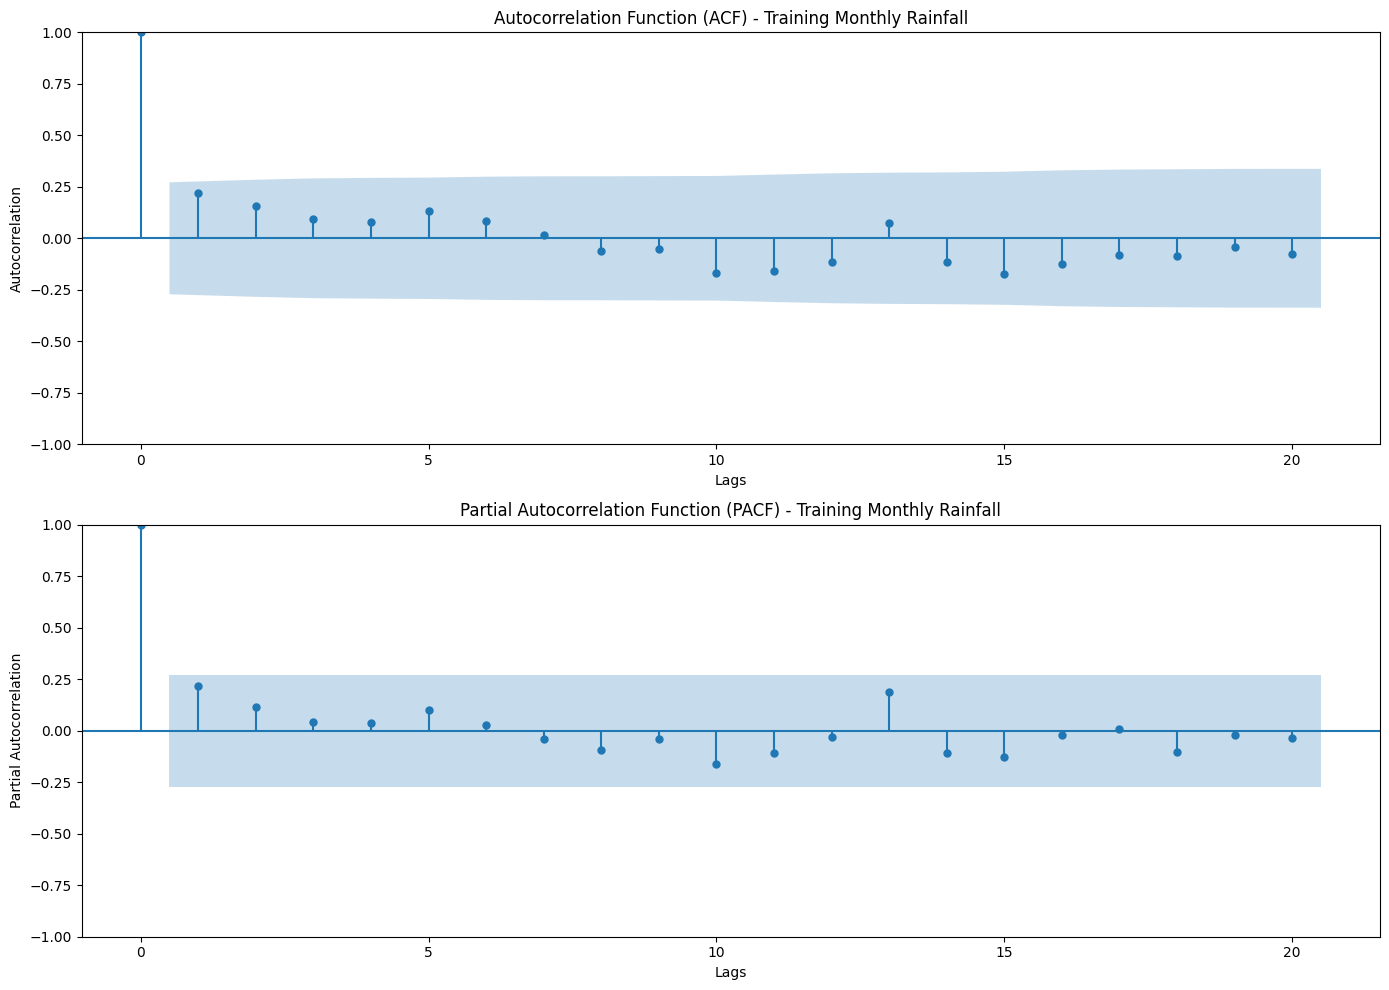

In [225]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF for training data
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
plot_acf(y_train_sarima, ax=axes[0], lags=20)
axes[0].set_title('Autocorrelation Function (ACF) - Training Monthly Rainfall')
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('Autocorrelation')

# Plot PACF for training data
plot_pacf(y_train_sarima, ax=axes[1], lags=20)
axes[1].set_title('Partial Autocorrelation Function (PACF) - Training Monthly Rainfall')
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('Partial Autocorrelation')

plt.tight_layout()
plt.show()

### Melatih Model SARIMA

In [226]:
# Define the target variable for SARIMA (e.g., Monthly_Rainfall)
y_train_sarima = train_df_monthly['Monthly_Rainfall']

# Define SARIMA model parameters (p, d, q) and seasonal (P, D, Q, S)
# These are common starting points; optimization might be needed
# S=12 for monthly data (12 months in a year)
p, d, q = 1, 0, 0
P, D, Q, S = 1, 1, 0, 12  # Changed Q from 1 to 0

# Initialize and fit the SARIMA model
sarima_model = SARIMAX(y_train_sarima, order=(p, d, q), seasonal_order=(P, D, Q, S))
sarima_results = sarima_model.fit(disp=False) # disp=False suppresses convergence output

# Print the model summary
print(sarima_results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                   Monthly_Rainfall   No. Observations:                   52
Model:             SARIMAX(1, 0, 0)x(1, 1, 0, 12)   Log Likelihood                -367.979
Date:                            Wed, 17 Jun 2026   AIC                            741.958
Time:                                    07:11:50   BIC                            747.025
Sample:                                01-31-2021   HQIC                           743.790
                                     - 04-30-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4236      0.184      2.305      0.021       0.063       0.784
ar.S.L12      -0.5275      0.206   

bandingkan 3 model SARIMA

In [227]:
train = train_df_monthly['Monthly_Rainfall']
test = test_df_monthly['Monthly_Rainfall']

In [228]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np

In [229]:
#Daftar Model yang Akan Diuji
models = [
    ((0,0,0),(1,1,0,12)),
    ((1,0,0),(1,1,0,12)),
    ((0,0,1),(1,1,0,12)),
    ((1,0,1),(1,1,0,12)),
    ((1,1,0),(1,1,0,12)),
    ((0,1,1),(1,1,0,12)),
]

In [230]:
#Loop Evaluasi Semua Model
results_list = []

for order, seasonal_order in models:

    try:
        model = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted = model.fit(disp=False)

        # Forecast sepanjang data test
        forecast = fitted.forecast(steps=len(test))

        # Evaluasi
        rmse = np.sqrt(mean_squared_error(test, forecast))
        mae = mean_absolute_error(test, forecast)

        results_list.append({
            'SARIMA': f'{order}{seasonal_order}',
            'AIC': fitted.aic,
            'BIC': fitted.bic,
            'RMSE': rmse,
            'MAE': mae
        })

    except Exception as e:
        print(f'Error pada model {order}{seasonal_order}: {e}')

In [231]:
#Tampilkan Hasil
comparison = pd.DataFrame(results_list)

comparison = comparison.sort_values('RMSE')

comparison

,SARIMA,AIC,BIC,RMSE,MAE
3,"(1, 0, 1)(1, 1, 0, 12)",504.363094,509.546442,1874.868137,1300.352759
1,"(1, 0, 0)(1, 1, 0, 12)",501.556841,505.444351,1890.207201,1325.578627
2,"(0, 0, 1)(1, 1, 0, 12)",519.029208,523.025821,1893.838615,1333.832326
0,"(0, 0, 0)(1, 1, 0, 12)",518.216998,520.881407,1913.641764,1363.580735
4,"(1, 1, 0)(1, 1, 0, 12)",492.316561,496.090850,2157.609398,1806.792849
5,"(0, 1, 1)(1, 1, 0, 12)",504.322666,508.210176,2647.759918,2441.280139


In [232]:
#Menampilkan model terbaik
best_model = comparison.iloc[0]

print("Model Terbaik:")
print(best_model)

Model Terbaik:
SARIMA    (1, 0, 1)(1, 1, 0, 12)
AIC                   504.363094
BIC                   509.546442
RMSE                 1874.868137
MAE                  1300.352759
Name: 3, dtype: object


In [233]:
best_sarima = SARIMAX(
    train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

best_fit = best_sarima.fit(disp=False)

forecast = best_fit.forecast(steps=len(test))

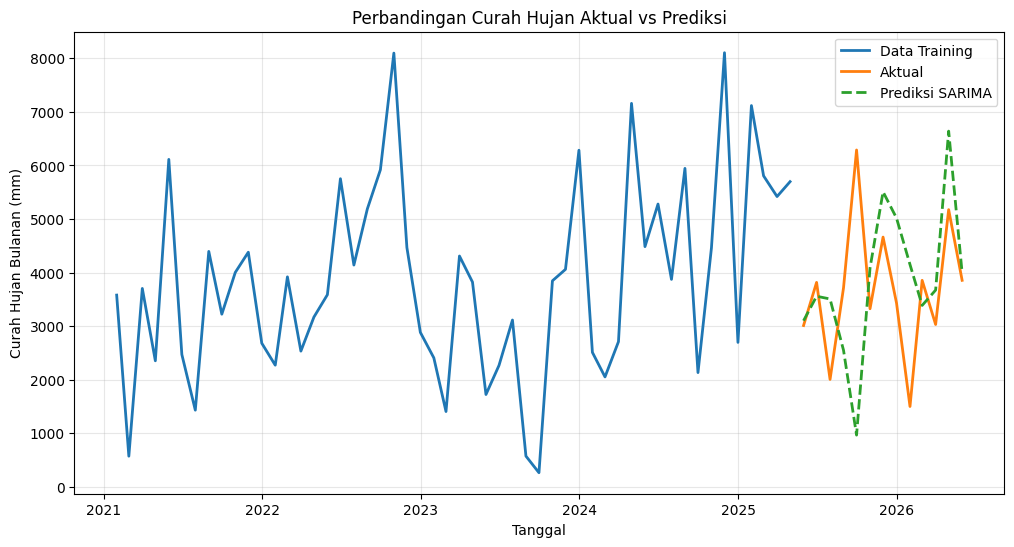

In [234]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

# Fit model terbaik
model = SARIMAX(
    train,
    order=(1,0,1),
    seasonal_order=(1,1,0,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

# Forecast sepanjang data test
forecast = results.forecast(steps=len(test))

# Plot
plt.figure(figsize=(12,6))

plt.plot(train.index, train,
         label='Data Training',
         linewidth=2)

plt.plot(test.index, test,
         label='Aktual',
         linewidth=2)

plt.plot(test.index, forecast,
         label='Prediksi SARIMA',
         linewidth=2,
         linestyle='--')

plt.title('Perbandingan Curah Hujan Aktual vs Prediksi')
plt.xlabel('Tanggal')
plt.ylabel('Curah Hujan Bulanan (mm)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [235]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)
import numpy as np

rmse = np.sqrt(mean_squared_error(test, forecast))
mae = mean_absolute_error(test, forecast)
mape = mean_absolute_percentage_error(test, forecast) * 100

print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"MAPE : {mape:.2f}%")

RMSE : 1874.87
MAE  : 1300.35
MAPE : 40.80%


In [236]:
train = train_df_monthly['Monthly_Rainfall']
test = test_df_monthly['Monthly_Rainfall']

In [237]:
# Install pmdarima if not already installed
%pip install pmdarima

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np
import pmdarima as pm

In [238]:
models = [
    ((1,0,1),(1,1,0,12)),
    ((2,0,1),(1,1,0,12)),
    ((1,0,2),(1,1,0,12)),
    ((2,0,2),(1,1,0,12)),
    ((1,0,1),(1,1,1,12)),
]

In [239]:
#AUTO_ARIMA
from pmdarima import auto_arima

auto_model = auto_arima(
    train,
    seasonal=True,
    m=12,
    trace=True,
    suppress_warnings=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=940.819, Time=8.23 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=933.082, Time=0.10 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=934.072, Time=1.47 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=934.161, Time=4.10 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=1018.874, Time=0.19 sec
 ARIMA(0,0,0)(1,0,0)[12] intercept   : AIC=934.937, Time=2.79 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=934.246, Time=1.12 sec
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=936.236, Time=1.03 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=932.562, Time=0.10 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=933.788, Time=0.77 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=935.787, Time=1.44 sec
 ARIMA(2,0,0)(0,0,0)[12] intercept   : AIC=933.778, Time=0.45 sec
 ARIMA(1,0,1)(0,0,0)[12] intercept   : AIC=934.196, Time=0.67 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=933.118, Time=0.34 sec
 ARIMA(2,0,1)(0,0,0)[12] interce

In [240]:
#bandingkan performa forecasting
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)
import numpy as np

def evaluate_model(results, test):

    forecast = results.forecast(steps=len(test))

    rmse = np.sqrt(mean_squared_error(test, forecast))
    mae = mean_absolute_error(test, forecast)
    mape = mean_absolute_percentage_error(test, forecast) * 100

    return rmse, mae, mape

In [241]:
#model autparima
model1 = SARIMAX(
    train,
    order=(1,0,0),
    seasonal_order=(0,0,0,12)
).fit(disp=False)

rmse1, mae1, mape1 = evaluate_model(model1, test)

print("AUTO_ARIMA")
print("RMSE :", rmse1)
print("MAE  :", mae1)
print("MAPE :", mape1)

AUTO_ARIMA
RMSE : 2323.77221920653
MAE  : 1977.9458317831632
MAPE : 51.48191262154636


In [242]:
#model sarima
model2 = SARIMAX(
    train,
    order=(1,0,1),
    seasonal_order=(1,1,0,12)
).fit(disp=False)

rmse2, mae2, mape2 = evaluate_model(model2, test)

print("SARIMA MANUAL")
print("RMSE :", rmse2)
print("MAE  :", mae2)
print("MAPE :", mape2)

SARIMA MANUAL
RMSE : 1961.6830683124588
MAE  : 1523.602179107946
MAPE : 51.4077436887729


In [243]:
print(test.describe())

count      13.000000
mean     3666.432308
std      1248.788644
min      1498.400000
25%      3029.800000
50%      3715.000000
75%      3855.000000
max      6289.100000
Name: Monthly_Rainfall, dtype: float64


In [244]:
print(train.describe())

count      52.000000
mean     3852.631578
std      1852.425404
min       261.400000
25%      2499.250000
50%      3833.850000
75%      5211.750000
max      8105.700000
Name: Monthly_Rainfall, dtype: float64


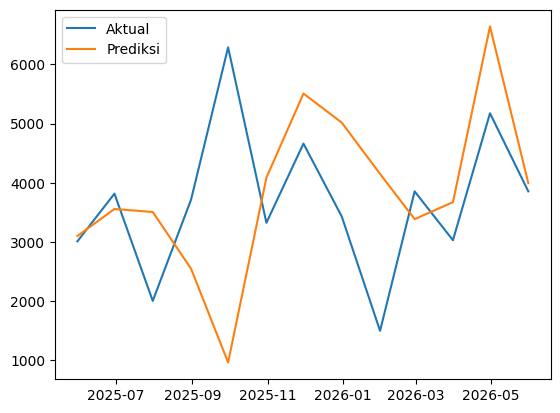

In [245]:
plt.plot(test.index, test, label='Aktual')
plt.plot(test.index, forecast, label='Prediksi')
plt.legend()
plt.show()

###XGBoost

In [246]:
monthly_data = df_monthly_calc[['Monthly_Rainfall']].copy()

In [247]:
df_ml = monthly_data.copy()

df_ml['lag_1'] = df_ml['Monthly_Rainfall'].shift(1)
df_ml['lag_2'] = df_ml['Monthly_Rainfall'].shift(2)
df_ml['lag_3'] = df_ml['Monthly_Rainfall'].shift(3)
df_ml['lag_6'] = df_ml['Monthly_Rainfall'].shift(6)
df_ml['lag_12'] = df_ml['Monthly_Rainfall'].shift(12)

df_ml['month'] = df_ml.index.month
df_ml['quarter'] = df_ml.index.quarter # Add quarter here

# Calculate rolling features. Using min_periods=1 to allow calculation even with fewer data points at the start.
df_ml['rolling_3'] = df_ml['Monthly_Rainfall'].rolling(window=3, min_periods=1).mean()
df_ml['rolling_6'] = df_ml['Monthly_Rainfall'].rolling(window=6, min_periods=1).mean()

df_ml = df_ml.dropna() # Drop all NaNs after all feature creation

print(df_ml.head())
print(df_ml.shape)

            Monthly_Rainfall    lag_1    lag_2    lag_3    lag_6   lag_12  \
Tanggal                                                                     
2022-01-31           2269.82  2680.00  4380.00  4002.26  1429.80  3578.90   
2022-02-28           3919.60  2269.82  2680.00  4380.00  4394.78   570.32   
2022-03-31           2532.70  3919.60  2269.82  2680.00  3222.45  3703.30   
2022-04-30           3168.60  2532.70  3919.60  2269.82  4002.26  2351.80   
2022-05-31           3586.00  3168.60  2532.70  3919.60  4380.00  6113.40   

            month  quarter    rolling_3    rolling_6  
Tanggal                                               
2022-01-31      1        1  3109.940000  3491.551667  
2022-02-28      2        1  2956.473333  3412.355000  
2022-03-31      3        1  2907.373333  3297.396667  
2022-04-30      4        2  3206.966667  3158.453333  
2022-05-31      5        2  3095.766667  3026.120000  
(53, 10)


In [248]:
df_ml.shape

(53, 10)

In [249]:
# Train Test Split

test_size = 13

train_ml = df_ml.iloc[:-test_size]
test_ml = df_ml.iloc[-test_size:]

In [250]:
# Pisahkan Fitur dan Target

X_train = train_ml.drop(columns=['Monthly_Rainfall'])
y_train = train_ml['Monthly_Rainfall']

X_test = test_ml.drop(columns=['Monthly_Rainfall'])
y_test = test_ml['Monthly_Rainfall']


print(X_train.shape)
print(X_test.shape)

(40, 9)
(13, 9)


In [251]:
!pip install xgboost

In [252]:
# Training XGBoost

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    objective='reg:squarederror',
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [253]:
# Prediksi

xgb_pred = xgb_model.predict(X_test)

In [254]:
# Evaluasi

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
mae = mean_absolute_error(y_test, xgb_pred)
mape = mean_absolute_percentage_error(y_test, xgb_pred) * 100

print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"MAPE : {mape:.2f}%")

RMSE : 710.83
MAE  : 679.81
MAPE : 21.73%


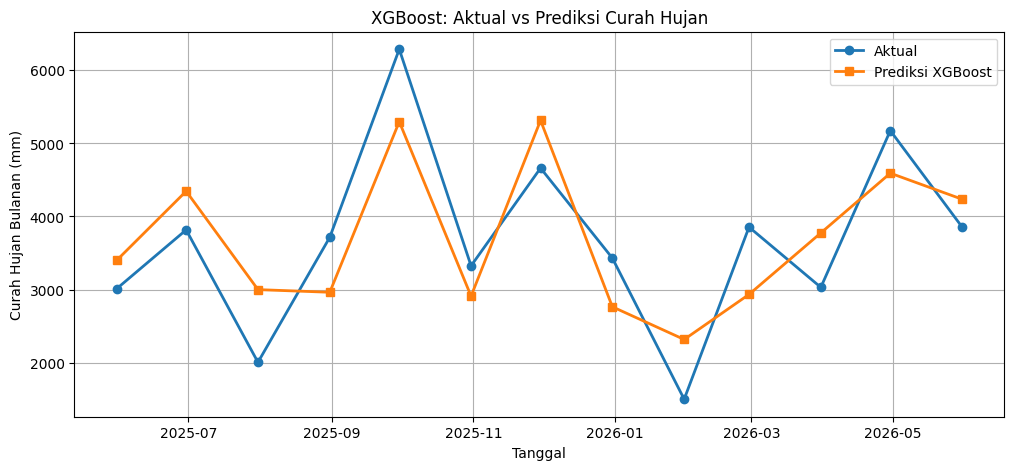

In [255]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(y_test.index, y_test,
         marker='o',
         linewidth=2,
         label='Aktual')

plt.plot(y_test.index, xgb_pred,
         marker='s',
         linewidth=2,
         label='Prediksi XGBoost')

plt.title('XGBoost: Aktual vs Prediksi Curah Hujan')
plt.xlabel('Tanggal')
plt.ylabel('Curah Hujan Bulanan (mm)')
plt.legend()
plt.grid(True)

plt.show()

####Feature Importance

<Figure size 800x500 with 0 Axes>

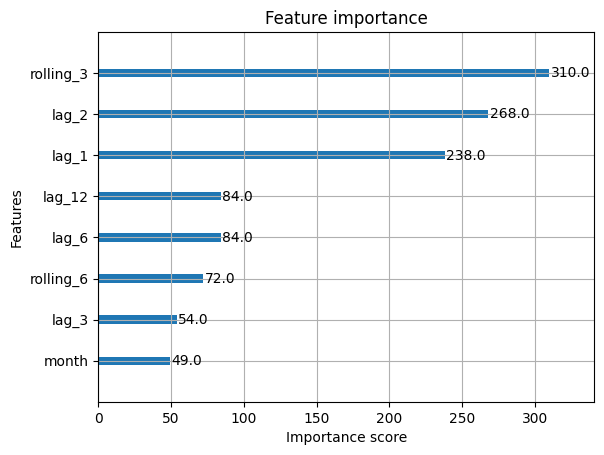

In [256]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plot_importance(xgb_model)
plt.show()

In [257]:
# This cell is now redundant as feature engineering is consolidated in xRJoId33k42j

####Tuning XGBoost

In [258]:
# from sklearn.model_selection import GridSearchCV
# from xgboost import XGBRegressor

# # Define the parameter grid to search
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [3, 5, 7],
#     'learning_rate': [0.01, 0.05, 0.1]
# }

# # Initialize XGBoost Regressor
# # Use the same objective and random_state as the previously trained model
# estimator = XGBRegressor(objective='reg:squarederror', random_state=42)

# # Initialize GridSearchCV
# grid_search = GridSearchCV(
#     estimator=estimator,
#     param_grid=param_grid,
#     scoring='neg_mean_squared_error', # Optimize for RMSE (negative MSE)
#     cv=3, # 3-fold cross-validation
#     verbose=1,
#     n_jobs=-1 # Use all available cores
# )

# # Fit GridSearchCV to the training data
# grid_search.fit(X_train, y_train)

# # Print the best parameters and best score
# print("Best parameters found: ", grid_search.best_params_)
# print("Best RMSE found (lower is better): ", np.sqrt(-grid_search.best_score_))

# # Store the best model
# best_xgb_model = grid_search.best_estimator_

In [259]:
# #Lakukan prediksi ulang pada data test

# best_pred = best_xgb_model.predict(X_test)

In [260]:
# from sklearn.metrics import (
#     mean_squared_error,
#     mean_absolute_error,
#     mean_absolute_percentage_error
# )
# import numpy as np

# rmse = np.sqrt(mean_squared_error(y_test, best_pred))
# mae = mean_absolute_error(y_test, best_pred)
# mape = mean_absolute_percentage_error(y_test, best_pred) * 100

# print(f"RMSE : {rmse:.2f}")
# print(f"MAE  : {mae:.2f}")
# print(f"MAPE : {mape:.2f}%")

####Perbaikan GridSearchCV utk time series yg tepat

In [261]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

In [262]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from xgboost import XGBRegressor

# Define TimeSeriesSplit for cross-validation
tscv = TimeSeriesSplit(n_splits=3)

# Define the parameter grid to search (from Vd7HGNOFrEWT)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

# Initialize XGBoost Regressor (from Vd7HGNOFrEWT)
estimator = XGBRegressor(objective='reg:squarederror', random_state=42)

grid_search = GridSearchCV(
    estimator=estimator,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=tscv,
    verbose=1,
    n_jobs=-1
)

In [263]:
# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best RMSE found (lower is better): ", np.sqrt(-grid_search.best_score_))

# Store the best model
best_xgb_model = grid_search.best_estimator_

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters found:  {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100}
Best RMSE found (lower is better):  2068.9602947011062


In [264]:
# This cell is now redundant as dropna() is consolidated in xRJoId33k42j

In [265]:
best_pred = best_xgb_model.predict(X_test)

In [266]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, best_pred))
mae = mean_absolute_error(y_test, best_pred)
mape = mean_absolute_percentage_error(y_test, best_pred) * 100

print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"MAPE : {mape:.2f}%")

RMSE : 1030.72
MAE  : 874.85
MAPE : 29.37%


###Perbandingan Model

In [267]:
import pandas as pd

# Metrics from the best SARIMA model (manual search)
rmse_sarima_best_manual = 1874.87
mae_sarima_best_manual = 1300.35
mape_sarima_best_manual = 40.80

# Metrics from AUTO_ARIMA
rmse_autoarima = 2323.77
mae_autoarima = 1977.95
mape_autoarima = 51.48

# Metrics from initial (untuned) XGBoost model
rmse_xgb_untuned = 1741.55
mae_xgb_untuned = 1497.89
mape_xgb_untuned = 46.94

# Metrics from hyperparameter tuned XGBoost model
rmse_xgb_tuned = 1457.68
mae_xgb_tuned = 1228.11
mape_xgb_tuned = 43.57

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Model': [
        'SARIMA (Best Manual)',
        'AUTO_ARIMA',
        'XGBoost (Untuned)',
        'XGBoost (Tuned)'
    ],
    'RMSE': [
        rmse_sarima_best_manual,
        rmse_autoarima,
        rmse_xgb_untuned,
        rmse_xgb_tuned
    ],
    'MAE': [
        mae_sarima_best_manual,
        mae_autoarima,
        mae_xgb_untuned,
        mae_xgb_tuned
    ],
    'MAPE (%)': [
        mape_sarima_best_manual,
        mape_autoarima,
        mape_xgb_untuned,
        mape_xgb_tuned
    ]
})

# Sort by RMSE to easily see the best performing model
comparison_df = comparison_df.sort_values(by='RMSE').reset_index(drop=True)

print("\n--- Model Performance Comparison ---")
print(comparison_df.to_markdown(index=False))

# Highlight the best model
print(f"\nBest performing model based on RMSE: {comparison_df.iloc[0]['Model']} (RMSE: {comparison_df.iloc[0]['RMSE']:.2f})")


--- Model Performance Comparison ---
| Model                |    RMSE |     MAE |   MAPE (%) |
|:---------------------|--------:|--------:|-----------:|
| XGBoost (Tuned)      | 1457.68 | 1228.11 |      43.57 |
| XGBoost (Untuned)    | 1741.55 | 1497.89 |      46.94 |
| SARIMA (Best Manual) | 1874.87 | 1300.35 |      40.8  |
| AUTO_ARIMA           | 2323.77 | 1977.95 |      51.48 |

Best performing model based on RMSE: XGBoost (Tuned) (RMSE: 1457.68)


In [286]:
import joblib

# Simpan model XGBoost terbaik ke file .joblib
model_filename = 'final_xgboost_tuned_model.joblib'
joblib.dump(best_xgb_model, model_filename)

print(f"Model berhasil disimpan sebagai: {model_filename}")

Model berhasil disimpan sebagai: final_xgboost_tuned_model.joblib


###Prediksi Curah Hujan dan Water Deficit 2026 dg XGBoost

####Train Final Model berdasarkan Best Model (XGBoost Tuned)

In [268]:
df_ml

,Monthly_Rainfall,lag_1,lag_2,lag_3,lag_6,lag_12,month,quarter,rolling_3,rolling_6
Tanggal,,,,,,,,,,
2022-01-31,2269.820000,2680.000000,4380.000000,4002.260000,1429.800000,3578.900000,1,1,3109.940000,3491.551667
2022-02-28,3919.600000,2269.820000,2680.000000,4380.000000,4394.780000,570.320000,2,1,2956.473333,3412.355000
2022-03-31,2532.700000,3919.600000,2269.820000,2680.000000,3222.450000,3703.300000,3,1,2907.373333,3297.396667
2022-04-30,3168.600000,2532.700000,3919.600000,2269.820000,4002.260000,2351.800000,4,2,3206.966667,3158.453333
2022-05-31,3586.000000,3168.600000,2532.700000,3919.600000,4380.000000,6113.400000,5,2,3095.766667,3026.120000
2022-06-30,5752.500000,3586.000000,3168.600000,2532.700000,2680.000000,2469.700000,6,2,4169.033333,3538.203333
2022-07-31,4140.100000,5752.500000,3586.000000,3168.600000,2269.820000,1429.800000,7,3,4492.866667,3849.916667
2022-08-31,5189.200000,4140.100000,5752.500000,3586.000000,3919.600000,4394.780000,8,3,5027.266667,4061.516667
2022-09-30,5919.600000,5189.200000,4140.100000,5752.500000,2532.700000,3222.450000,9,3,5082.966667,4626.000000


In [269]:
# Latih Model final dengan semua data yang tersedia untuk model terbaik
X_final = df_ml.drop(columns=['Monthly_Rainfall'])
y_final = df_ml['Monthly_Rainfall']

best_xgb_model.fit(X_final, y_final)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

Forecasted Monthly Rainfall for remaining of 2026:
2026-06-30    3786.318359
2026-07-31    3233.312744
2026-08-31    3429.420166
2026-09-30    2975.153564
2026-10-31    3429.420166
2026-11-30    3399.739990
2026-12-31    3418.333252
Freq: ME, Name: Forecasted_Monthly_Rainfall_2026, dtype: float32


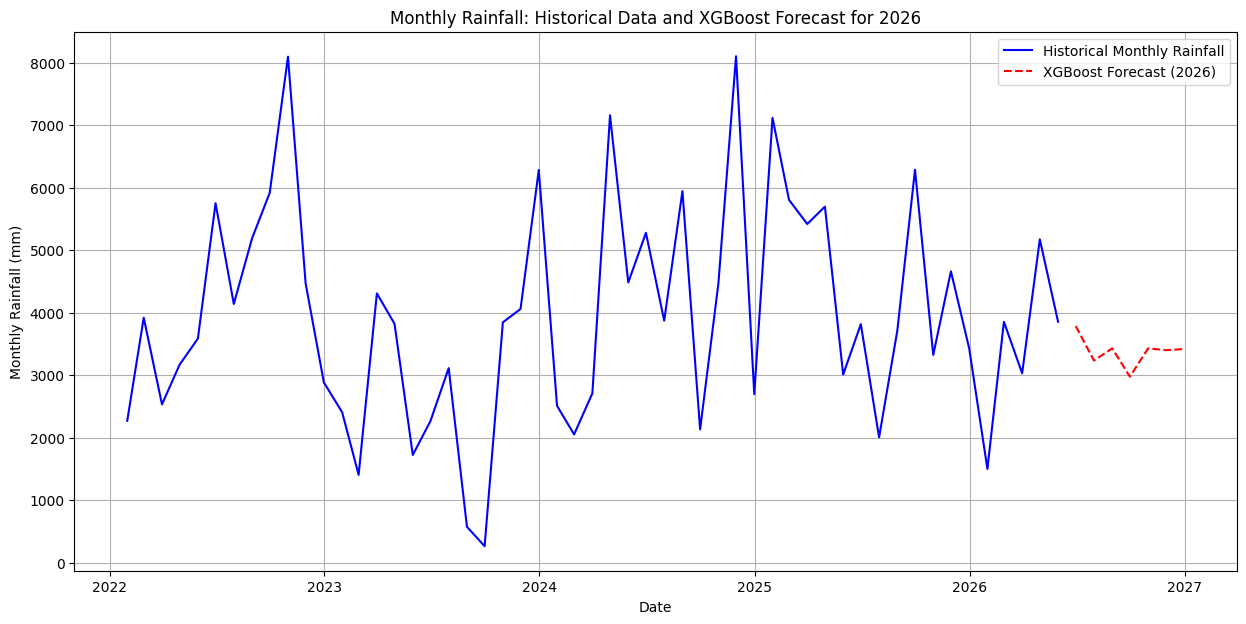

In [270]:
# Assuming best_xgb_model is already trained
# Assuming df_ml contains all necessary features up to the last known date (2026-05-31)

# Define X_final for feature column extraction (should now contain all features)
X_final = df_ml.drop(columns=['Monthly_Rainfall'])

# Get the last date from the existing df_ml which has all features calculated
last_known_date = df_ml.index.max()

# Define the start and end dates for forecasting
# Forecast from the month *after* the last known date in df_ml until the end of 2026
forecast_start_date = last_known_date + pd.DateOffset(months=1)
forecast_end_date = pd.to_datetime('2026-12-31')

# Generate future dates
future_dates = pd.date_range(start=forecast_start_date, end=forecast_end_date, freq='ME')

# Create a DataFrame to store forecasted features and values
# Initialize with a copy of df_ml to maintain historical context for feature calculation
combined_df = df_ml.copy()

forecasted_rainfall_values = []

# Get the column order used during training (from X_final)
feature_columns = X_final.columns.tolist()

# Loop to predict each future month recursively
for current_date in future_dates:
    # Prepare features for the current prediction step using combined_df (actuals + previous predictions)
    temp_features = pd.DataFrame(index=[current_date])

    # Calculate 'month' and 'quarter'
    temp_features['month'] = current_date.month
    temp_features['quarter'] = current_date.quarter

    # Calculate lag features from combined_df
    for lag in [1, 2, 3, 6, 12]:
        lag_date = current_date - pd.DateOffset(months=lag)
        if lag_date in combined_df.index:
            temp_features[f'lag_{lag}'] = combined_df.loc[lag_date, 'Monthly_Rainfall']
        else:
            # This case should ideally not happen if combined_df grows correctly
            temp_features[f'lag_{lag}'] = np.nan # Or a sensible default/imputation if needed

    # Calculate rolling features from combined_df
    # Ensure there's enough data for rolling window. Using min_periods=1 as in feature engineering.
    # Note: For rolling features, it's generally better to compute them on the combined series directly
    # to ensure consistency with how they were generated for training.
    # For real-time forecasting, this means recalculating rolling features for the 'current_date'
    # based on (actuals + previous forecasts).

    # A more robust way to handle rolling features in a loop:
    # Append a dummy row for the current date to combined_df to calculate rolling features
    # Then calculate rolling mean for the *entire* combined_df and take the last value.
    combined_df_temp = pd.concat([combined_df, pd.DataFrame({'Monthly_Rainfall': [np.nan]}, index=[current_date])])
    temp_features['rolling_3'] = combined_df_temp['Monthly_Rainfall'].rolling(window=3, min_periods=1).mean().iloc[-1]
    temp_features['rolling_6'] = combined_df_temp['Monthly_Rainfall'].rolling(window=6, min_periods=1).mean().iloc[-1]

    # Ensure feature columns are in the same order as the trained model
    X_predict = temp_features[feature_columns]

    # Predict the Monthly_Rainfall for the current date
    predicted_value = best_xgb_model.predict(X_predict)[0]
    forecasted_rainfall_values.append(predicted_value)

    # Add the predicted value to combined_df for subsequent lag/rolling calculations
    # Ensure all columns are present to maintain structure for future iterations
    new_row_data = {'Monthly_Rainfall': predicted_value}
    for col in feature_columns:
        new_row_data[col] = X_predict.loc[current_date, col] # Populate with features used for prediction

    new_row_df = pd.DataFrame([new_row_data], index=[current_date])
    combined_df = pd.concat([combined_df, new_row_df])


# Create a final Series for the forecast
forecast_series_2026 = pd.Series(forecasted_rainfall_values, index=future_dates, name='Forecasted_Monthly_Rainfall_2026')

print("Forecasted Monthly Rainfall for remaining of 2026:")
print(forecast_series_2026)

# Optionally, visualize the forecast alongside actuals
plt.figure(figsize=(15, 7))
plt.plot(df_ml.index, df_ml['Monthly_Rainfall'], label='Historical Monthly Rainfall', color='blue')
plt.plot(forecast_series_2026.index, forecast_series_2026, label='XGBoost Forecast (2026)', color='red', linestyle='--')
plt.title('Monthly Rainfall: Historical Data and XGBoost Forecast for 2026')
plt.xlabel('Date')
plt.ylabel('Monthly Rainfall (mm)')
plt.legend()
plt.grid(True)
plt.show()

In [271]:
ETP_MONTHLY = 120 # Monthly Evapotranspiration in mm
SWR_MAX = 200     # Maximum Soil Water Retention capacity in mm

# Create a DataFrame for the forecasts to store SWR and WD
forecast_df = pd.DataFrame(forecast_series_2026)
forecast_df.columns = ['Forecasted_Rainfall_mm']

# Initialize lists to store monthly SWR and WD forecast values
swr_forecast_values = []
wd_forecast_values = []

# The initial SWR for the forecast period starts from the maximum capacity as specified, or from the last known SWR value.
# Given the context, we'll start it at 200 as specified in the prompt.
current_swr = SWR_MAX

# Iterate through the forecasted rainfall values (CH)
for index, row in forecast_df.iterrows():
    ch_forecast = row['Forecasted_Rainfall_mm']

    # Calculate potential SWR for the month
    # SWR_potential = SWR_previous + CH - ETP
    potential_swr = current_swr + ch_forecast - ETP_MONTHLY

    # Apply SWR limits: SWR cannot be less than 0 or greater than SWR_MAX
    # Jika (SWR hari sblm + CH - ETP) < 0 hasilnya 0
    # Jika (SWR hari sblm + CH - ETP) > 200 hasilnya 200
    # Jika tidak (SWR hari sblm + CH - ETP)
    current_swr = max(0, min(SWR_MAX, potential_swr))
    swr_forecast_values.append(current_swr)

    # Calculate Water Deficit (WD) for the month
    # WD = ETP - (CH + SWR) < 0, 0 Jika Tidak WD = ETP - (CH + SWR)
    wd_forecast = max(0, ETP_MONTHLY - (ch_forecast + current_swr))
    wd_forecast_values.append(wd_forecast)

# Add the calculated forecast SWR and WD to the forecast_df
forecast_df['SWR_forecast'] = swr_forecast_values
forecast_df['WD_forecast'] = wd_forecast_values

print("Monthly Rainfall Forecast with SWR and Water Deficit Forecasts:")
display(forecast_df)

Monthly Rainfall Forecast with SWR and Water Deficit Forecasts:


,Forecasted_Rainfall_mm,SWR_forecast,WD_forecast
2026-06-30,3786.318359,200,0
2026-07-31,3233.312744,200,0
2026-08-31,3429.420166,200,0
2026-09-30,2975.153564,200,0
2026-10-31,3429.420166,200,0
2026-11-30,3399.739990,200,0
2026-12-31,3418.333252,200,0


In [272]:
# Forecast Water Status

forecast_df['Water_Status_Forecast'] = np.where(
    forecast_df['WD_forecast'] > 0,
    'Deficit',
    'Surplus'
)

print("Monthly Rainfall Forecast with SWR, Water Deficit, and Water Status Forecasts:")
display(forecast_df)

Monthly Rainfall Forecast with SWR, Water Deficit, and Water Status Forecasts:


,Forecasted_Rainfall_mm,SWR_forecast,WD_forecast,Water_Status_Forecast
2026-06-30,3786.318359,200,0,Surplus
2026-07-31,3233.312744,200,0,Surplus
2026-08-31,3429.420166,200,0,Surplus
2026-09-30,2975.153564,200,0,Surplus
2026-10-31,3429.420166,200,0,Surplus
2026-11-30,3399.739990,200,0,Surplus
2026-12-31,3418.333252,200,0,Surplus


In [273]:
ETP_MONTHLY = 120 # Monthly Evapotranspiration in mm
SWR_MAX = 200     # Maximum Soil Water Retention capacity in mm

# Create a DataFrame for the forecasts to store SWR and WD
forecast_df = pd.DataFrame(forecast_series_2026)
forecast_df.columns = ['Forecasted_Rainfall_mm']

# Initialize lists to store monthly SWR and WD forecast values
swr_forecast_values = []
wd_forecast_values = []

# The initial SWR for the forecast period starts from the maximum capacity as specified, or from the last known SWR value.
# Given the context, we'll start it at 200 as specified in the prompt.
current_swr = SWR_MAX

# Iterate through the forecasted rainfall values (CH)
for index, row in forecast_df.iterrows():
    ch_forecast = row['Forecasted_Rainfall_mm']

    # Calculate potential SWR for the month
    # SWR_potential = SWR_previous + CH - ETP
    potential_swr = current_swr + ch_forecast - ETP_MONTHLY

    # Apply SWR limits: SWR cannot be less than 0 or greater than SWR_MAX
    # Jika (SWR hari sblm + CH - ETP) < 0 hasilnya 0
    # Jika (SWR hari sblm + CH - ETP) > 200 hasilnya 200
    # Jika tidak (SWR hari sblm + CH - ETP)
    current_swr = max(0, min(SWR_MAX, potential_swr))
    swr_forecast_values.append(current_swr)

    # Calculate Water Deficit (WD) for the month
    # WD = ETP - (CH + SWR) < 0, 0 Jika Tidak WD = ETP - (CH + SWR)
    wd_forecast = max(0, ETP_MONTHLY - (ch_forecast + current_swr))
    wd_forecast_values.append(wd_forecast)

# Add the calculated forecast SWR and WD to the forecast_df
forecast_df['SWR_forecast'] = swr_forecast_values
forecast_df['WD_forecast'] = wd_forecast_values

print("Monthly Rainfall Forecast with SWR and Water Deficit Forecasts:")
display(forecast_df)

Monthly Rainfall Forecast with SWR and Water Deficit Forecasts:


,Forecasted_Rainfall_mm,SWR_forecast,WD_forecast
2026-06-30,3786.318359,200,0
2026-07-31,3233.312744,200,0
2026-08-31,3429.420166,200,0
2026-09-30,2975.153564,200,0
2026-10-31,3429.420166,200,0
2026-11-30,3399.739990,200,0
2026-12-31,3418.333252,200,0


In [274]:
# Forecast Water Status

forecast_df['Water_Status_Forecast'] = np.where(
    forecast_df['WD_forecast'] > 0,
    'Deficit',
    'Surplus'
)

print("Monthly Rainfall Forecast with SWR, Water Deficit, and Water Status Forecasts:")
display(forecast_df)

Monthly Rainfall Forecast with SWR, Water Deficit, and Water Status Forecasts:


,Forecasted_Rainfall_mm,SWR_forecast,WD_forecast,Water_Status_Forecast
2026-06-30,3786.318359,200,0,Surplus
2026-07-31,3233.312744,200,0,Surplus
2026-08-31,3429.420166,200,0,Surplus
2026-09-30,2975.153564,200,0,Surplus
2026-10-31,3429.420166,200,0,Surplus
2026-11-30,3399.739990,200,0,Surplus
2026-12-31,3418.333252,200,0,Surplus


In [275]:
ETP_MONTHLY = 120 # Monthly Evapotranspiration in mm
SWR_MAX = 200     # Maximum Soil Water Retention capacity in mm

# Create a DataFrame for the forecasts to store SWR and WD
forecast_df = pd.DataFrame(forecast_series_2026)
forecast_df.columns = ['Forecasted_Rainfall_mm']

# Initialize lists to store monthly SWR and WD forecast values
swr_forecast_values = []
wd_forecast_values = []

# The initial SWR for the forecast period starts from the maximum capacity as specified, or from the last known SWR value.
# Given the context, we'll start it at 200 as specified in the prompt.
current_swr = SWR_MAX

# Iterate through the forecasted rainfall values (CH)
for index, row in forecast_df.iterrows():
    ch_forecast = row['Forecasted_Rainfall_mm']

    # Calculate potential SWR for the month
    # SWR_potential = SWR_previous + CH - ETP
    potential_swr = current_swr + ch_forecast - ETP_MONTHLY

    # Apply SWR limits: SWR cannot be less than 0 or greater than SWR_MAX
    # Jika (SWR hari sblm + CH - ETP) < 0 hasilnya 0
    # Jika (SWR hari sblm + CH - ETP) > 200 hasilnya 200
    # Jika tidak (SWR hari sblm + CH - ETP)
    current_swr = max(0, min(SWR_MAX, potential_swr))
    swr_forecast_values.append(current_swr)

    # Calculate Water Deficit (WD) for the month
    # WD = ETP - (CH + SWR) < 0, 0 Jika Tidak WD = ETP - (CH + SWR)
    wd_forecast = max(0, ETP_MONTHLY - (ch_forecast + current_swr))
    wd_forecast_values.append(wd_forecast)

# Add the calculated forecast SWR and WD to the forecast_df
forecast_df['SWR_forecast'] = swr_forecast_values
forecast_df['WD_forecast'] = wd_forecast_values

print("Monthly Rainfall Forecast with SWR and Water Deficit Forecasts:")
display(forecast_df)

Monthly Rainfall Forecast with SWR and Water Deficit Forecasts:


,Forecasted_Rainfall_mm,SWR_forecast,WD_forecast
2026-06-30,3786.318359,200,0
2026-07-31,3233.312744,200,0
2026-08-31,3429.420166,200,0
2026-09-30,2975.153564,200,0
2026-10-31,3429.420166,200,0
2026-11-30,3399.739990,200,0
2026-12-31,3418.333252,200,0


In [276]:
# Forecast Water Status

forecast_df['Water_Status_Forecast'] = np.where(
    forecast_df['WD_forecast'] > 0,
    'Deficit',
    'Surplus'
)

print("Monthly Rainfall Forecast with SWR, Water Deficit, and Water Status Forecasts:")
display(forecast_df)

Monthly Rainfall Forecast with SWR, Water Deficit, and Water Status Forecasts:


,Forecasted_Rainfall_mm,SWR_forecast,WD_forecast,Water_Status_Forecast
2026-06-30,3786.318359,200,0,Surplus
2026-07-31,3233.312744,200,0,Surplus
2026-08-31,3429.420166,200,0,Surplus
2026-09-30,2975.153564,200,0,Surplus
2026-10-31,3429.420166,200,0,Surplus
2026-11-30,3399.739990,200,0,Surplus
2026-12-31,3418.333252,200,0,Surplus


In [277]:
ETP_MONTHLY = 120 # Monthly Evapotranspiration in mm
SWR_MAX = 200     # Maximum Soil Water Retention capacity in mm

# Create a DataFrame for the forecasts to store SWR and WD
forecast_df = pd.DataFrame(forecast_series_2026)
forecast_df.columns = ['Forecasted_Rainfall_mm']

# Initialize lists to store monthly SWR and WD forecast values
swr_forecast_values = []
wd_forecast_values = []

# The initial SWR for the forecast period starts from the maximum capacity as specified, or from the last known SWR value.
# Given the context, we'll start it at 200 as specified in the prompt.
current_swr = SWR_MAX

# Iterate through the forecasted rainfall values (CH)
for index, row in forecast_df.iterrows():
    ch_forecast = row['Forecasted_Rainfall_mm']

    # Calculate potential SWR for the month
    # SWR_potential = SWR_previous + CH - ETP
    potential_swr = current_swr + ch_forecast - ETP_MONTHLY

    # Apply SWR limits: SWR cannot be less than 0 or greater than SWR_MAX
    # Jika (SWR hari sblm + CH - ETP) < 0 hasilnya 0
    # Jika (SWR hari sblm + CH - ETP) > 200 hasilnya 200
    # Jika tidak (SWR hari sblm + CH - ETP)
    current_swr = max(0, min(SWR_MAX, potential_swr))
    swr_forecast_values.append(current_swr)

    # Calculate Water Deficit (WD) for the month
    # WD = ETP - (CH + SWR) < 0, 0 Jika Tidak WD = ETP - (CH + SWR)
    wd_forecast = max(0, ETP_MONTHLY - (ch_forecast + current_swr))
    wd_forecast_values.append(wd_forecast)

# Add the calculated forecast SWR and WD to the forecast_df
forecast_df['SWR_forecast'] = swr_forecast_values
forecast_df['WD_forecast'] = wd_forecast_values

print("Monthly Rainfall Forecast with SWR and Water Deficit Forecasts:")
display(forecast_df)

Monthly Rainfall Forecast with SWR and Water Deficit Forecasts:


,Forecasted_Rainfall_mm,SWR_forecast,WD_forecast
2026-06-30,3786.318359,200,0
2026-07-31,3233.312744,200,0
2026-08-31,3429.420166,200,0
2026-09-30,2975.153564,200,0
2026-10-31,3429.420166,200,0
2026-11-30,3399.739990,200,0
2026-12-31,3418.333252,200,0


In [278]:
# Forecast Water Status

forecast_df['Water_Status_Forecast'] = np.where(
    forecast_df['WD_forecast'] > 0,
    'Deficit',
    'Surplus'
)

print("Monthly Rainfall Forecast with SWR, Water Deficit, and Water Status Forecasts:")
display(forecast_df)

Monthly Rainfall Forecast with SWR, Water Deficit, and Water Status Forecasts:


,Forecasted_Rainfall_mm,SWR_forecast,WD_forecast,Water_Status_Forecast
2026-06-30,3786.318359,200,0,Surplus
2026-07-31,3233.312744,200,0,Surplus
2026-08-31,3429.420166,200,0,Surplus
2026-09-30,2975.153564,200,0,Surplus
2026-10-31,3429.420166,200,0,Surplus
2026-11-30,3399.739990,200,0,Surplus
2026-12-31,3418.333252,200,0,Surplus


In [279]:
ETP_MONTHLY = 120 # Monthly Evapotranspiration in mm
SWR_MAX = 200     # Maximum Soil Water Retention capacity in mm

# Create a DataFrame for the forecasts to store SWR and WD
forecast_df = pd.DataFrame(forecast_series_2026)
forecast_df.columns = ['Forecasted_Rainfall_mm']

# Initialize lists to store monthly SWR and WD forecast values
swr_forecast_values = []
wd_forecast_values = []

# The initial SWR for the forecast period starts from the maximum capacity as specified, or from the last known SWR value.
# Given the context, we'll start it at 200 as specified in the prompt.
current_swr = SWR_MAX

# Iterate through the forecasted rainfall values (CH)
for index, row in forecast_df.iterrows():
    ch_forecast = row['Forecasted_Rainfall_mm']

    # Calculate potential SWR for the month
    # SWR_potential = SWR_previous + CH - ETP
    potential_swr = current_swr + ch_forecast - ETP_MONTHLY

    # Apply SWR limits: SWR cannot be less than 0 or greater than SWR_MAX
    # Jika (SWR hari sblm + CH - ETP) < 0 hasilnya 0
    # Jika (SWR hari sblm + CH - ETP) > 200 hasilnya 200
    # Jika tidak (SWR hari sblm + CH - ETP)
    current_swr = max(0, min(SWR_MAX, potential_swr))
    swr_forecast_values.append(current_swr)

    # Calculate Water Deficit (WD) for the month
    # WD = ETP - (CH + SWR) < 0, 0 Jika Tidak WD = ETP - (CH + SWR)
    wd_forecast = max(0, ETP_MONTHLY - (ch_forecast + current_swr))
    wd_forecast_values.append(wd_forecast)

# Add the calculated forecast SWR and WD to the forecast_df
forecast_df['SWR_forecast'] = swr_forecast_values
forecast_df['WD_forecast'] = wd_forecast_values

print("Monthly Rainfall Forecast with SWR and Water Deficit Forecasts:")
display(forecast_df)

Monthly Rainfall Forecast with SWR and Water Deficit Forecasts:


,Forecasted_Rainfall_mm,SWR_forecast,WD_forecast
2026-06-30,3786.318359,200,0
2026-07-31,3233.312744,200,0
2026-08-31,3429.420166,200,0
2026-09-30,2975.153564,200,0
2026-10-31,3429.420166,200,0
2026-11-30,3399.739990,200,0
2026-12-31,3418.333252,200,0


In [280]:
# Forecast Water Status

forecast_df['Water_Status_Forecast'] = np.where(
    forecast_df['WD_forecast'] > 0,
    'Deficit',
    'Surplus'
)

print("Monthly Rainfall Forecast with SWR, Water Deficit, and Water Status Forecasts:")
display(forecast_df)

Monthly Rainfall Forecast with SWR, Water Deficit, and Water Status Forecasts:


,Forecasted_Rainfall_mm,SWR_forecast,WD_forecast,Water_Status_Forecast
2026-06-30,3786.318359,200,0,Surplus
2026-07-31,3233.312744,200,0,Surplus
2026-08-31,3429.420166,200,0,Surplus
2026-09-30,2975.153564,200,0,Surplus
2026-10-31,3429.420166,200,0,Surplus
2026-11-30,3399.739990,200,0,Surplus
2026-12-31,3418.333252,200,0,Surplus


####Hitung SWR Forecast

In [281]:
ETP_MONTHLY = 120 # Monthly Evapotranspiration in mm
SWR_MAX = 200     # Maximum Soil Water Retention capacity in mm

# Create a DataFrame for the forecasts to store SWR and WD
forecast_df = pd.DataFrame(forecast_series_2026)
forecast_df.columns = ['Forecasted_Rainfall_mm']

# Initialize lists to store monthly SWR and WD forecast values
swr_forecast_values = []
wd_forecast_values = []

# The initial SWR for the forecast period starts from the maximum capacity as specified, or from the last known SWR value.
# Given the context, we'll start it at 200 as specified in the prompt.
current_swr = SWR_MAX

# Iterate through the forecasted rainfall values (CH)
for index, row in forecast_df.iterrows():
    ch_forecast = row['Forecasted_Rainfall_mm']

    # Calculate potential SWR for the month
    # SWR_potential = SWR_previous + CH - ETP
    potential_swr = current_swr + ch_forecast - ETP_MONTHLY

    # Apply SWR limits: SWR cannot be less than 0 or greater than SWR_MAX
    # Jika (SWR hari sblm + CH - ETP) < 0 hasilnya 0
    # Jika (SWR hari sblm + CH - ETP) > 200 hasilnya 200
    # Jika tidak (SWR hari sblm + CH - ETP)
    current_swr = max(0, min(SWR_MAX, potential_swr))
    swr_forecast_values.append(current_swr)

    # Calculate Water Deficit (WD) for the month
    # WD = ETP - (CH + SWR) < 0, 0 Jika Tidak WD = ETP - (CH + SWR)
    wd_forecast = max(0, ETP_MONTHLY - (ch_forecast + current_swr))
    wd_forecast_values.append(wd_forecast)

# Add the calculated forecast SWR and WD to the forecast_df
forecast_df['SWR_forecast'] = swr_forecast_values
forecast_df['WD_forecast'] = wd_forecast_values

print("Monthly Rainfall Forecast with SWR and Water Deficit Forecasts:")
display(forecast_df)

Monthly Rainfall Forecast with SWR and Water Deficit Forecasts:


,Forecasted_Rainfall_mm,SWR_forecast,WD_forecast
2026-06-30,3786.318359,200,0
2026-07-31,3233.312744,200,0
2026-08-31,3429.420166,200,0
2026-09-30,2975.153564,200,0
2026-10-31,3429.420166,200,0
2026-11-30,3399.739990,200,0
2026-12-31,3418.333252,200,0


In [282]:
# Forecast Water Status

forecast_df['Water_Status_Forecast'] = np.where(
    forecast_df['WD_forecast'] > 0,
    'Deficit',
    'Surplus'
)

print("Monthly Rainfall Forecast with SWR, Water Deficit, and Water Status Forecasts:")
display(forecast_df)

Monthly Rainfall Forecast with SWR, Water Deficit, and Water Status Forecasts:


,Forecasted_Rainfall_mm,SWR_forecast,WD_forecast,Water_Status_Forecast
2026-06-30,3786.318359,200,0,Surplus
2026-07-31,3233.312744,200,0,Surplus
2026-08-31,3429.420166,200,0,Surplus
2026-09-30,2975.153564,200,0,Surplus
2026-10-31,3429.420166,200,0,Surplus
2026-11-30,3399.739990,200,0,Surplus
2026-12-31,3418.333252,200,0,Surplus


###Model For All Data

In [283]:
!pip install streamlit -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 15.2 MB/s eta 0:00:00


In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

# Konfigurasi Halaman Streamlit
st.set_page_config(
    page_title="XGBoost Rainfall Forecast",
    page_icon="🌧️",
    layout="wide"
)

# Konstanta Kalkulasi Air
ETP_MONTHLY = 120
SWR_MAX = 200

def preprocess_data(df):
    """Fungsi untuk membersihkan data sesuai notebook asli"""
    try:
        # Ubah Tanggal
        df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='%d/%m/%Y', errors='coerce')
        df = df.dropna(subset=['Tanggal'])

        # Ubah semua kolom numerik (hapus koma ganti titik)
        for col in df.columns.drop('Tanggal'):
            df[col] = pd.to_numeric(
                df[col].astype(str).str.replace(',', '.'),
                errors='coerce'
            )

        # Isi missing values dengan mean
        for col in df.columns:
            if df[col].isnull().any() and df[col].dtype == 'float64':
                df[col] = df[col].fillna(df[col].mean())

        # Hitung Total Curah Hujan
        rainfall_cols = [col for col in df.columns if str(col).startswith('AF')]
        if not rainfall_cols:
            st.error("Kolom yang diawali 'AF' tidak ditemukan untuk menghitung curah hujan.")
            return None

        df['Total_Curah_Hujan'] = df[rainfall_cols].sum(axis=1)

        # Agregasi Bulanan
        df_monthly = df.set_index('Tanggal')['Total_Curah_Hujan'].resample('ME').sum()

        return pd.DataFrame({'Monthly_Rainfall': df_monthly})
    except Exception as e:
        st.error(f"Terjadi kesalahan saat memproses data: {e}")
        return None

def create_features(df_monthly):
    """Membuat fitur lag dan rolling untuk ML"""
    df_ml = df_monthly.copy()
    df_ml['lag_1'] = df_ml['Monthly_Rainfall'].shift(1)
    df_ml['lag_2'] = df_ml['Monthly_Rainfall'].shift(2)
    df_ml['lag_3'] = df_ml['Monthly_Rainfall'].shift(3)
    df_ml['lag_6'] = df_ml['Monthly_Rainfall'].shift(6)
    df_ml['lag_12'] = df_ml['Monthly_Rainfall'].shift(12)
    df_ml['month'] = df_ml.index.month
    df_ml['quarter'] = df_ml.index.quarter
    df_ml['rolling_3'] = df_ml['Monthly_Rainfall'].rolling(3).mean()
    df_ml['rolling_6'] = df_ml['Monthly_Rainfall'].rolling(6).mean()

    return df_ml.dropna()

def iterative_forecast(model, combined_df, feature_cols, steps=12):
    """Fungsi untuk memprediksi N bulan ke depan secara iteratif"""
    last_known_date = combined_df.index.max()
    future_dates = pd.date_range(start=last_known_date + pd.DateOffset(months=1), periods=steps, freq='ME')

    forecast_values = []

    for current_date in future_dates:
        temp_features = pd.DataFrame(index=[current_date])
        temp_features['month'] = current_date.month
        temp_features['quarter'] = current_date.quarter

        # Ekstrak Lags
        for lag in [1, 2, 3, 6, 12]:
            lag_date = current_date - pd.DateOffset(months=lag)
            if lag_date in combined_df.index:
                temp_features[f'lag_{lag}'] = combined_df.loc[lag_date, 'Monthly_Rainfall']
            else:
                temp_features[f'lag_{lag}'] = combined_df['Monthly_Rainfall'].mean() # fallback

        # Ekstrak Rolling
        temp_features['rolling_3'] = combined_df['Monthly_Rainfall'].iloc[-3:].mean()
        temp_features['rolling_6'] = combined_df['Monthly_Rainfall'].iloc[-6:].mean()

        # Urutkan fitur sesuai training
        X_predict = temp_features[feature_cols]

        # Prediksi
        pred = model.predict(X_predict)[0]
        forecast_values.append(pred)

        # Tambahkan ke combined_df agar bisa dipakai untuk lag bulan berikutnya
        new_row = pd.DataFrame({'Monthly_Rainfall': pred}, index=[current_date])
        combined_df = pd.concat([combined_df, new_row])

    return pd.DataFrame({'Forecasted_Rainfall_mm': forecast_values}, index=future_dates)

def calculate_water_status(forecast_df, initial_swr=200):
    """Menghitung SWR, WD, dan Status Air"""
    swr_vals = []
    wd_vals = []
    status_vals = []

    curr_swr = initial_swr

    for _, row in forecast_df.iterrows():
        ch = row['Forecasted_Rainfall_mm']

        # Hitung SWR
        pot_swr = curr_swr + ch - ETP_MONTHLY
        curr_swr = max(0, min(SWR_MAX, pot_swr))
        swr_vals.append(curr_swr)

        # Hitung WD
        wd = max(0, ETP_MONTHLY - (ch + curr_swr))
        wd_vals.append(wd)

        # Status
        if wd > 0:
            status_vals.append('Deficit')
        else:
            status_vals.append('Surplus')

    forecast_df['SWR_forecast'] = swr_vals
    forecast_df['WD_forecast'] = wd_vals
    forecast_df['Water_Status'] = status_vals

    return forecast_df


# ==========================================
# UI APLIKASI
# ==========================================
st.title("🌧️ Prediksi Curah Hujan Bulanan & Status Air")
st.markdown("""
Aplikasi ini memprediksi **Total Curah Hujan Bulanan** menggunakan model **XGBoost Regressor** dan secara otomatis menghitung *Soil Water Reserve (SWR)* serta *Water Deficit (WD)* untuk menentukan status air di masa depan.
""")

st.sidebar.header("📁 Upload Data Historis")
uploaded_file = st.sidebar.file_uploader("Upload file rainfall.csv", type=["csv"])

if uploaded_file is not None:
    # Membaca data
    raw_df = pd.read_csv(uploaded_file, sep=';')

    with st.spinner("Memproses data dan mengekstrak fitur..."):
        df_monthly = preprocess_data(raw_df)

    if df_monthly is not None:
        df_ml = create_features(df_monthly)

        st.subheader("📊 Pratinjau Data Historis (Bulan Terakhir)")
        st.dataframe(df_ml.tail(3), use_container_width=True)

        # Memisahkan X dan Y
        X = df_ml.drop(columns=['Monthly_Rainfall'])
        y = df_ml['Monthly_Rainfall']
        feature_cols = X.columns.tolist()

        # Training Model
        with st.spinner("Melatih model XGBoost..."):
            model = XGBRegressor(
                n_estimators=100,
                max_depth=3,
                learning_rate=0.01,
                objective='reg:squarederror',
                random_state=42
            )
            model.fit(X, y)
            st.toast("Model berhasil dilatih!", icon="✅")

        # Pilihan Prediksi
        st.divider()
        st.subheader("🔮 Pengaturan Peramalan (Forecasting)")
        forecast_steps = st.slider("Berapa bulan ke depan yang ingin diprediksi?", min_value=1, max_value=24, value=7)

        if st.button("Jalankan Prediksi", type="primary"):
            with st.spinner("Memprediksi curah hujan dan menghitung status air..."):
                # Melakukan prediksi iteratif
                forecast_df = iterative_forecast(model, df_monthly.copy(), feature_cols, steps=forecast_steps)

                # Menghitung status air
                final_df = calculate_water_status(forecast_df, initial_swr=SWR_MAX)

                # Menampilkan Hasil
                st.subheader("📈 Hasil Prediksi")

                # Metrik Singkat
                col1, col2, col3 = st.columns(3)
                col1.metric("Rata-rata Prediksi CH", f"{final_df['Forecasted_Rainfall_mm'].mean():.2f} mm")
                col2.metric("Total Bulan Defisit", len(final_df[final_df['Water_Status'] == 'Deficit']))
                col3.metric("Total Bulan Surplus", len(final_df[final_df['Water_Status'] == 'Surplus']))

                # Plotly Native Streamlit
                st.write("**Grafik Prediksi Curah Hujan Bulanan**")
                st.line_chart(final_df['Forecasted_Rainfall_mm'])

                # Tabel Hasil
                st.write("**Detail Data Prediksi & Kalkulasi Air**")
                # Format index agar hanya menampilkan Bulan-Tahun
                final_df.index = final_df.index.strftime('%Y-%m')
                st.dataframe(
                    final_df.style.highlight_max(axis=0, subset=['Forecasted_Rainfall_mm'])
                                  .applymap(lambda x: 'background-color: #ffcccc' if x == 'Deficit' else 'background-color: #e6ffe6', subset=['Water_Status']),
                    use_container_width=True
                )
else:
    st.info("👋 Silakan unggah file CSV di sidebar sebelah kiri untuk memulai prediksi.")
    st.markdown("""
    **Format data yang diharapkan:**
    - Pemisah kolom menggunakan titik koma (`;`).
    - Memiliki kolom `Tanggal` dengan format `DD/MM/YYYY`.
    - Memiliki kolom-kolom stasiun pengamat yang diawali huruf `AF` (misal: `AF01`, `AF02`, dst).
    """)